# Laboratorium 8 – Zastosowania deep learning w przetwarzaniu obrazów
**Analiza i przetwarzanie obrazów**  
AGH, Informatyka Stosowana II st., Semestr I

## Przegląd bibliotek i zasobów

### Rozpoznawanie twarzy
| Projekt | Opis | Link |
|---------|------|------|
| **face_recognition** | Oparta o dlib, wykrywa elementy twarzy (oczy, usta) | [GitHub](https://github.com/ageitgey/face_recognition) |
| **DeepFace** | VGG-Face, FaceNet, OpenFace, DeepFace – analiza twarzy | [GitHub](https://github.com/serengil/deepface) |
| **Keras facial features** | Rozpoznawanie cech twarzy (Keras) | [Tutorial](https://www.kdnuggets.com/2017/09/detecting-facial-features-deep-learning.html) |
| **Emotion recognition** | Rozpoznawanie nastroju (Keras + TF) | [Tutorial](https://sefiks.com/2018/01/01/facial-expression-recognition-with-keras/) |

### Detekcja obiektów i OCR
| Projekt | Opis | Link |
|---------|------|------|
| **Real-time detection** | Detekcja w wideo krok po kroku (OpenCV + DL) | [pyimagesearch](https://www.pyimagesearch.com/2017/09/18/real-time-object-detection-with-deep-learning-and-opencv/) |
| **OCR tutorial** | Gentle intro to OCR, datasety, TF+Keras | [towardsdatascience](https://towardsdatascience.com/a-gentle-introduction-to-ocr-ee1469a201aa) |

### Efekty i generowanie
| Projekt | Opis | Link |
|---------|------|------|
| **Style Transfer** | Neural style transfer (TensorFlow) | [datacamp](https://www.datacamp.com/community/tutorials/implementing-neural-style-transfer-using-tensorflow) |
| **Image Inpainting** | Uzupełnianie brakujących fragmentów (GMCNN) | [GitHub](https://github.com/shepnerd/inpainting_gmcnn) |
| **Super-resolution** | Bez GAN (deep learning) | [towardsdatascience](https://towardsdatascience.com/deep-learning-based-super-resolution-without-using-a-gan-11c9bb5b6cd5) |
| **Pix2Pix GAN** | Mapy ze zdjęć satelitarnych | [machinelearningmastery](https://machinelearningmastery.com/how-to-develop-a-pix2pix-gan-for-image-to-image-translation/) |

### Śledzenie postępu
- Najnowsze prace z kodami: [paperswithcode.com/area/computer-vision](https://paperswithcode.com/area/computer-vision)
- Krótkie filmy o osiągnięciach AI: [Two Minute Papers](https://www.youtube.com/channel/UCbfYPyITQ-7l4upoX8nvctg)

## Demo praktyczne – DeepFace: analiza twarzy

In [ ]:
%pip install deepface -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Action: race: 100%|██████████| 4/4 [00:00<00:00, 21.82it/s]   



Twarz 1:
  Wiek:    36
  Płeć:    Woman  (100.0%)
  Emocja:  angry

Twarz 2:
  Wiek:    41
  Płeć:    Woman  (79.8%)
  Emocja:  angry

Twarz 3:
  Wiek:    23
  Płeć:    Man  (98.3%)
  Emocja:  angry

Twarz 4:
  Wiek:    36
  Płeć:    Man  (100.0%)
  Emocja:  neutral

Twarz 5:
  Wiek:    24
  Płeć:    Man  (99.1%)
  Emocja:  fear

Twarz 6:
  Wiek:    45
  Płeć:    Woman  (93.5%)
  Emocja:  sad

Twarz 7:
  Wiek:    47
  Płeć:    Man  (100.0%)
  Emocja:  angry

Twarz 8:
  Wiek:    50
  Płeć:    Man  (100.0%)
  Emocja:  angry

Twarz 9:
  Wiek:    41
  Płeć:    Man  (99.5%)
  Emocja:  happy

Twarz 10:
  Wiek:    48
  Płeć:    Man  (100.0%)
  Emocja:  neutral

Twarz 11:
  Wiek:    54
  Płeć:    Woman  (99.8%)
  Emocja:  neutral

Twarz 12:
  Wiek:    39
  Płeć:    Man  (99.5%)
  Emocja:  happy

Twarz 13:
  Wiek:    33
  Płeć:    Man  (91.5%)
  Emocja:  angry

Twarz 14:
  Wiek:    43
  Płeć:    Man  (99.9%)
  Emocja:  fear

Twarz 15:
  Wiek:    38
  Płeć:    Man  (100.0%)
  Emocja:  fear

Twa

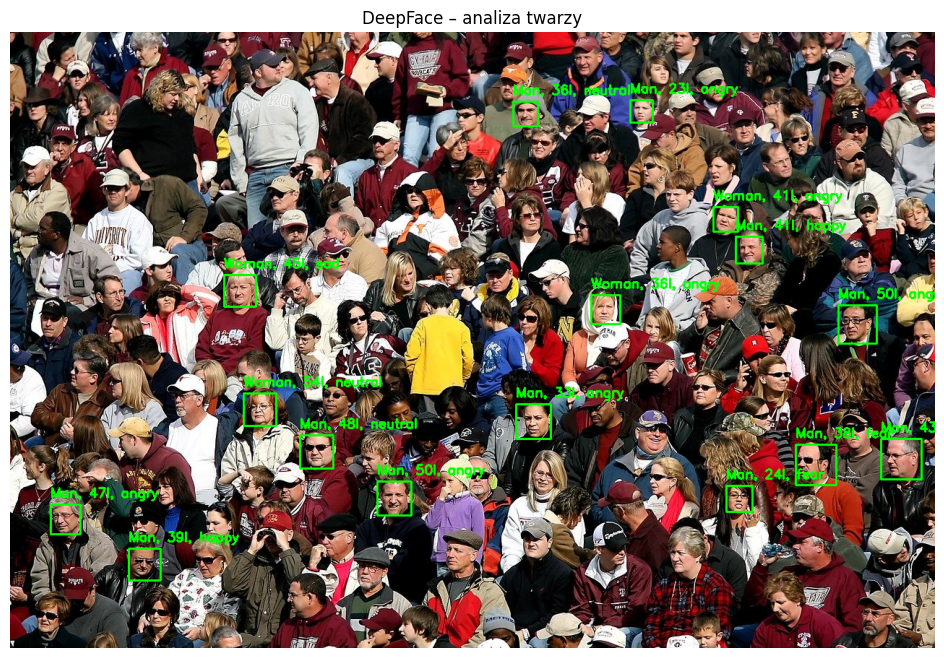

In [1]:
import cv2
from matplotlib import pyplot as plt
from deepface import DeepFace

plt.rcParams['figure.figsize'] = [16, 8]

img_path = '../images/lab1.jpg'  # obraz z twarzą z lab 1

# Analiza: wiek, płeć, emocja, rasa – modele pobierane przy pierwszym uruchomieniu
results = DeepFace.analyze(img_path, actions=['age', 'gender', 'emotion', 'race'], enforce_detection=False)

img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
for i, r in enumerate(results if isinstance(results, list) else [results]):
    print(f"\nTwarz {i+1}:")
    print(f"  Wiek:    {r['age']}")
    print(f"  Płeć:    {r['dominant_gender']}  ({r['gender'][r['dominant_gender']]:.1f}%)")
    print(f"  Emocja:  {r['dominant_emotion']}")
    region = r.get('region', {})
    if region:
        x, y, w, h = region['x'], region['y'], region['w'], region['h']
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        label = f"{r['dominant_gender']}, {r['age']}l, {r['dominant_emotion']}"
        cv2.putText(img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

plt.imshow(img); plt.axis('off'); plt.title('DeepFace – analiza twarzy'); plt.show()

## Uwagi

- **DeepFace** przy pierwszym uruchomieniu pobiera modele (~100–500 MB) do `~/.deepface/weights/`
- Domyślny backend to VGG-Face; można zmienić: `model_name='Facenet'`
- Do rozpoznawania **obiektów** (nie twarzy) w wideo polecany pipeline: **YOLOv8** (ultralytics) lub **OpenCV DNN** z modelem SSD/MobileNet